## LEVEL 1 PROJECT 2
## By Devansh Ketan Panchal

In [31]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.3 MB 1.1 MB/s eta 0:00:08
    --------------------------------------- 0.2/8.3 MB 1.8 MB/s eta 0:00:05
   - -------------------------------------- 0.4/8.3 MB 2.8 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.3 MB 2.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/8.3 MB 5.0 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.3 MB 4.8 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 5.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 6.3 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.3 M


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition

### Importing Dataset

In [2]:
df = pd.read_csv("C:/Users/91812/Desktop/Internship/Oasis Infobyte/Datasets/ifood_df.csv")

In [3]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


### Data Exploration and Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3          2205 non-n

In [5]:
df.isna().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

#### No Missing Value Dataset Containes 2205 Records.
#### Also the Datatype of all feature are apprioprite

In [6]:
## Accssing the unique values of the columns
print(df.nunique())

Income                  1963
Kidhome                    3
Teenhome                   3
Recency                  100
MntWines                 775
MntFruits                158
MntMeatProducts          551
MntFishProducts          182
MntSweetProducts         176
MntGoldProds             212
NumDealsPurchases         15
NumWebPurchases           15
NumCatalogPurchases       13
NumStorePurchases         14
NumWebVisitsMonth         16
AcceptedCmp3               2
AcceptedCmp4               2
AcceptedCmp5               2
AcceptedCmp1               2
AcceptedCmp2               2
Complain                   2
Z_CostContact              1
Z_Revenue                  1
Response                   2
Age                       56
Customer_Days            662
marital_Divorced           2
marital_Married            2
marital_Single             2
marital_Together           2
marital_Widow              2
education_2n Cycle         2
education_Basic            2
education_Graduation       2
education_Mast

#### As we can see that there is only a single value in the column: Z_CostContact & Z_Revenue, hence no need of those columns

In [7]:
df.drop(["Z_CostContact","Z_Revenue"], inplace=True, axis=1)

### Descriptive Statistics

In [8]:
df['Complain'].sum()

np.int64(20)

#### There are 20 Customers who have complained in last 2 years

### Box plot for total amount spend on all products

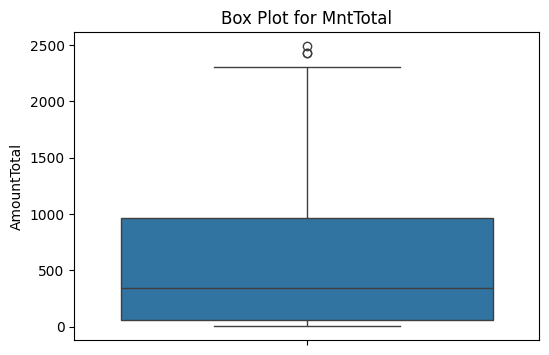

In [10]:
plt.figure(figsize=(6, 4))  
sns.boxplot(data=df, y='MntTotal')
plt.title('Box Plot for MntTotal')
plt.ylabel('AmountTotal')
plt.show()

### Box Plot and histogram for income

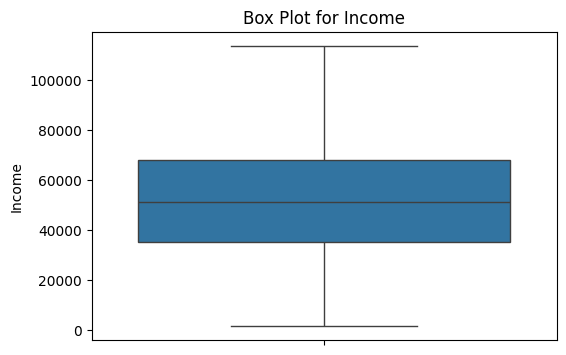

In [14]:
plt.figure(figsize=(6, 4))  
sns.boxplot(data=df, y='Income')
plt.title('Box Plot for Income')
plt.ylabel('Income')
plt.show()

### We can see that the IQR of income lies between 30,000 - 70,000

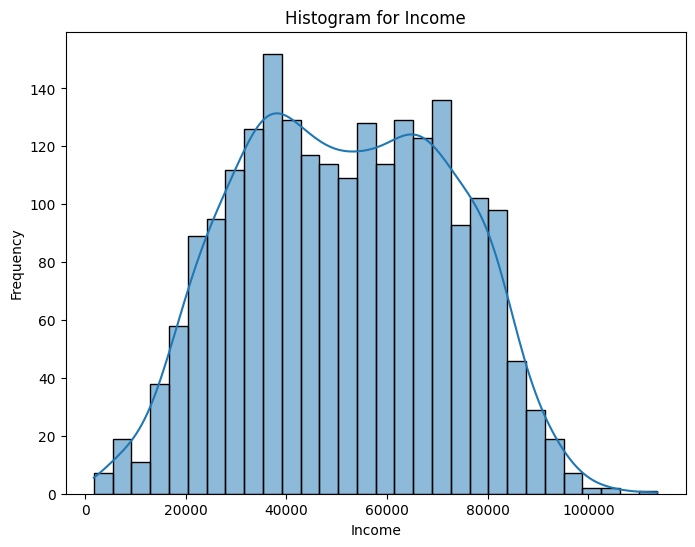

In [12]:
plt.figure(figsize=(8, 6))  
sns.histplot(data=df, x='Income', bins=30, kde=True)
plt.title('Histogram for Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

### We can see that maximum people's income 30,000 - 40,000

### Age Distribution

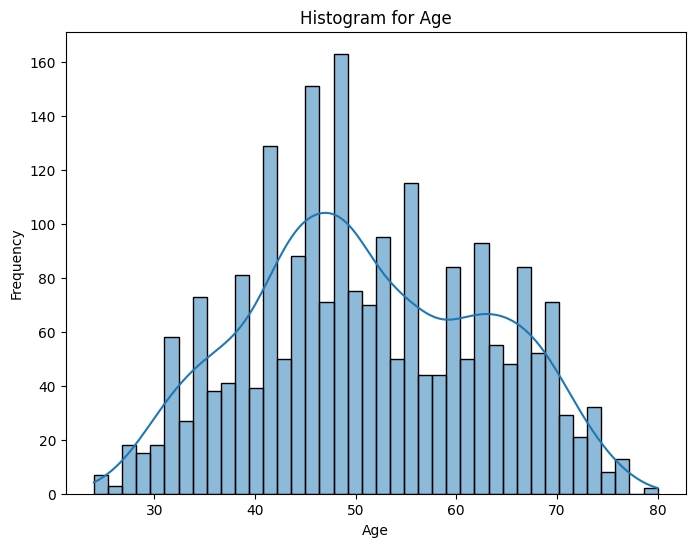

In [17]:
plt.figure(figsize=(8, 6))  
sns.histplot(data=df, x='Age', bins=40, kde=True)
plt.title('Histogram for Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### We can see that the maximum peoples age lies between 41 - 49 years

## Segrigating columns 

In [18]:
col_demographics = ['Income','Age']
col_children = ['Kidhome', 'Teenhome']
col_marital = ['marital_Divorced', 'marital_Married','marital_Single', 'marital_Together', 'marital_Widow']
col_mnt = ['MntTotal', 'MntRegularProds','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
col_communication = ['Complain', 'Response', 'Customer_Days']
col_campaigns = ['AcceptedCmpOverall', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
col_source_of_purchase = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
col_education = ['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']

### Correlation matrix

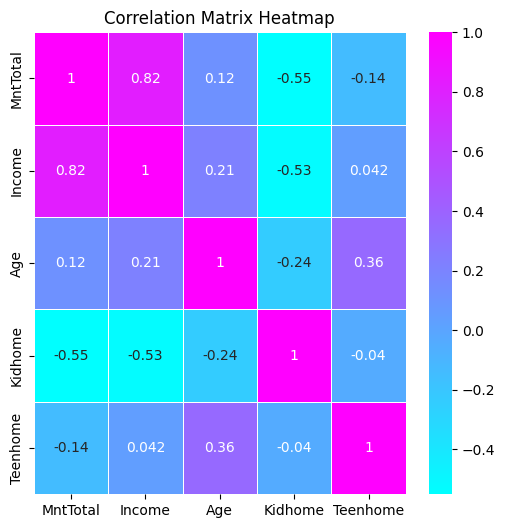

In [24]:
corr_matrix = df[['MntTotal']+col_demographics+col_children].corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap = 'cool', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Here we can see that MntTotal has strong positive correlation with income and intermediate negative correlation with Kidhome.

### The data frame contains 5 columns to reflect marital status. We are going to create a new column 'marital' with values: Divorced, Married, Single, Together, Widow merged in a single.

In [25]:
def get_marital_status(row):
    if row['marital_Divorced'] == 1:
        return 'Divorced'
    elif row['marital_Married'] == 1:
        return 'Married'
    elif row['marital_Single'] == 1:
        return 'Single'
    elif row['marital_Together'] == 1:
        return 'Together'
    elif row['marital_Widow'] == 1:
        return 'Widow'
    else:
        return 'Unknown'
df['Marital'] = df.apply(get_marital_status, axis=1)

Text(0, 0.5, 'MntTotal')

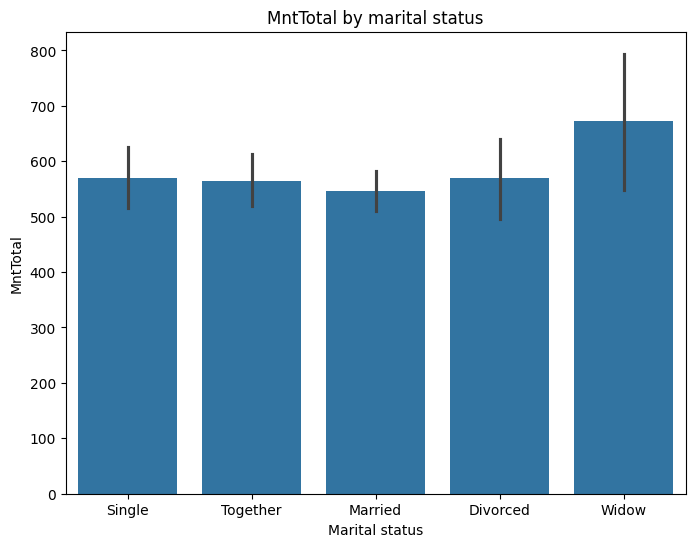

In [26]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Marital', y='MntTotal', data=df)
plt.title('MntTotal by marital status')
plt.xlabel('Marital status')
plt.ylabel('MntTotal')

### There are 3 features that reflect if a person is single (Single, Divorced, Widow) and 2 features if a person is in relationship (Together, Married). We will add an additional feature 'In_relationship'. This feature will equal 1 if a customer's marital status is 'Married' or 'Together' and 0 in all other cases.

In [27]:
def get_relationship(row):
    if row['marital_Married'] ==1:
        return 1
    elif row['marital_Together'] == 1:
        return 1
    else:
        return 0
df['In_relationship'] = df.apply(get_relationship, axis=1)


In [28]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Marital,In_relationship
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,1,0,0,1529,1441,0,Single,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,1,0,0,21,15,0,Single,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,1,0,0,734,692,0,Together,1
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,1,0,0,48,43,0,Together,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,1,407,392,0,Married,1


## K - Means Clustering

### Reducing the distance berween the points by Scaling it using Standard Scaler

In [33]:
scaler = StandardScaler()
col_for_clustering = ['Income', 'MntTotal', 'In_relationship']
data_scaled = df.copy()
data_scaled[col_for_clustering] = scaler.fit_transform(df[col_for_clustering])
data_scaled[col_for_clustering].describe()

,Income,MntTotal,In_relationship
count,2.205000e+03,2.205000e+03,2.205000e+03
mean,2.255691e-17,-3.705778e-17,6.444832e-17
std,1.000227e+00,1.000227e+00,1.000227e+00
min,-2.409272e+00,-9.704038e-01,-1.347625e+00
25%,-7.932106e-01,-8.800957e-01,-1.347625e+00
50%,-1.618161e-02,-3.816642e-01,7.420464e-01
75%,8.044529e-01,6.968235e-01,7.420464e-01
max,2.999363e+00,3.348757e+00,7.420464e-01


### Doing PCA to reduce the dimensionality and capturing the featues that has the most variance 

In [ ]:
pca = decomposition.PCA(n_components = 2)
pca_res = pca.fit_transform(data_scaled[col_for_clustering])
data_scaled['pc1'] = pca_res[:,0]
data_scaled['pc2'] = pca_res[:,1]

### Uising elbow method for selecting the number of clusters

In [35]:
X = data_scaled[col_for_clustering]
inertia_list = []
for K in range(2,10):
    inertia = KMeans(n_clusters=K, random_state=7).fit(X).inertia_
    inertia_list.append(inertia)

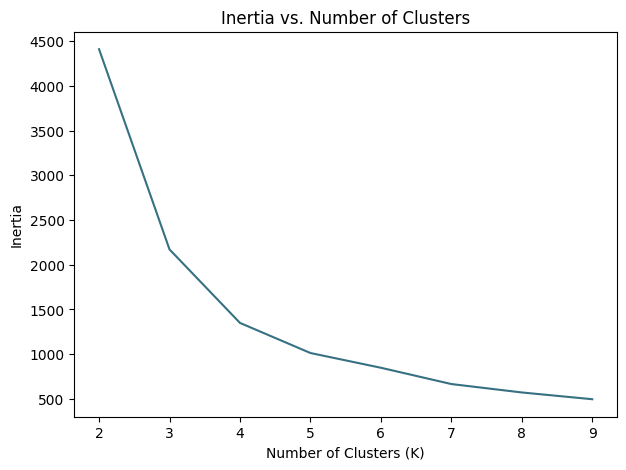

In [36]:
plt.figure(figsize=[7,5])
plt.plot(range(2,10), inertia_list, color=(54 / 255, 113 / 255, 130 / 255))
plt.title("Inertia vs. Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

### It suggestd 4-5 clusters

## Modeling for 4 clusters

In [37]:
model = KMeans(n_clusters=4, random_state = 7)
model.fit(data_scaled[col_for_clustering])
data_scaled['Cluster'] = model.predict(data_scaled[col_for_clustering])

### Visualizing clusters

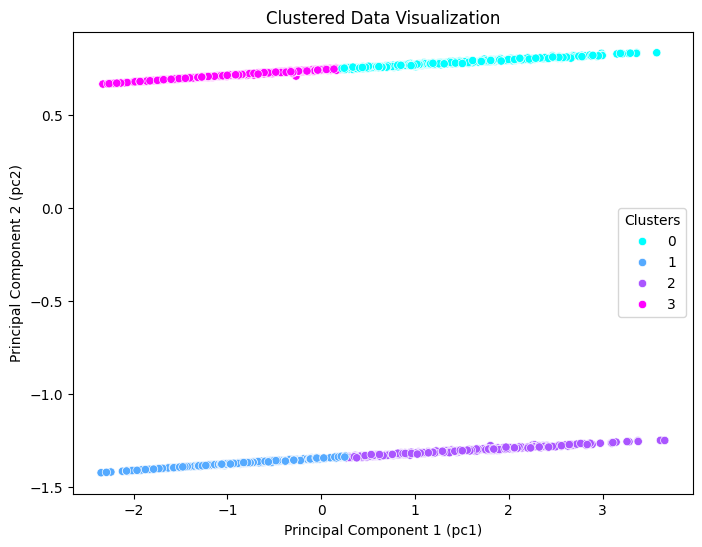

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pc1', y='pc2', data=data_scaled, hue='Cluster', palette='cool')
plt.title('Clustered Data Visualization')
plt.xlabel('Principal Component 1 (pc1)')
plt.ylabel('Principal Component 2 (pc2)')
plt.legend(title='Clusters')

### Cluster Sizes

C:\Users\91812\AppData\Local\Temp\ipykernel_27492\3716200502.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='MntTotal', data=cluster_sizes, palette = 'viridis')


Text(0, 0.5, 'MntTotal')

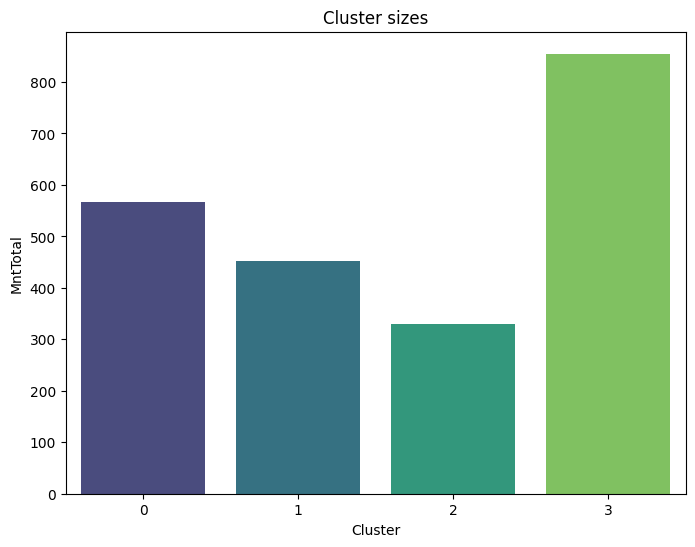

In [43]:
cluster_sizes = data_scaled.groupby('Cluster')[['MntTotal']].count().reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='Cluster', y='MntTotal', data=cluster_sizes, palette = 'viridis')
plt.title('Cluster sizes')
plt.xlabel('Cluster')
plt.ylabel('MntTotal')

## Cluster Characteristics

## Cluster 0: High value customers in relationship (either married or together)
This cluster represents 26% of the customer base
These customers have high income and they are in a relationship

## Cluster 1: Low value single customers
This cluster represents 21% of the customer base
These customers have low income and they are single

## Cluster 2: High value single customers
This cluster represents 15% of the customer base
These customers have high income and they are single

## Cluster 3: Low value customers in relationship
This cluster represents 39% of the customer base
These customers have low income and they are in a relationship